Second RNN GridWorld Experiment
Goal: Increase the number of trajectories (batches) used for training in the RNN

Results observation: 

In [121]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Imports

In [122]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import functions.trajectories as trajectories
import functions.NN_models as NN_models
import functions.gridworld as gridworld
import functions.model_training_evaluator as model_training_evaluator
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

print(sys.executable)
print(torch.__version__)

/home/seblee/miniconda3/envs/main/bin/python
2.14.0+cu130


State variables

In [123]:

HEIGHT = 29
WIDTH = 36
VIEW_SIZE = 5

START_X = 7
START_Y = 7
START_DIRECTION = 2

N_STEPS = 500

ACTION_PROBS = [0.6, 0.15, 0.15, 0.1]

SEED = 42


TEST_SEED = 123
TEST_STEPS = 200

Gridworld Creation

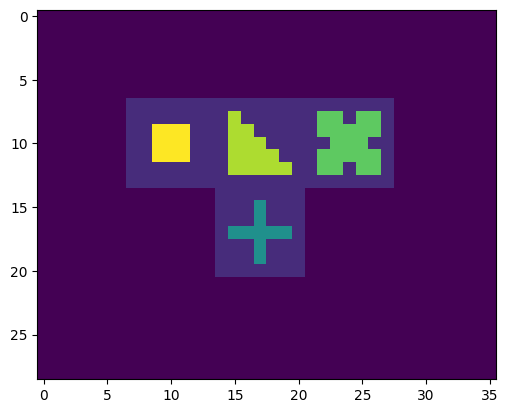

In [124]:
grid = gridworld.GridWorld(HEIGHT, WIDTH)
grid.add_rectangle_region(7, 14, 7, 28)
grid.add_rectangle_region(14, 21, 14, 21)
grid.add_square_shape(9, 9, 3, 7)
grid.add_triangle_shape(8, 15, 5, 0, 6)
grid.add_square_shape(9, 23, 3, 5)
grid.add_square_shape(8, 22, 2, 5)
grid.add_square_shape(11, 22, 2, 5)
grid.add_square_shape(11, 25, 2, 5)
grid.add_square_shape(8, 25, 2, 5)
grid.add_rectangle_shape(15, 17, 5, 1, 3)
grid.add_rectangle_shape(17, 15, 1, 5, 3)
grid.randomXYStart(SEED)
plt.imshow(grid.grid)


NN Training and Validation

501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])
targets:  torch.Size([500, 25])
501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])
targets:  torch.Size([500, 25])
501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])
targets:  torch.Size([500, 25])
501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])


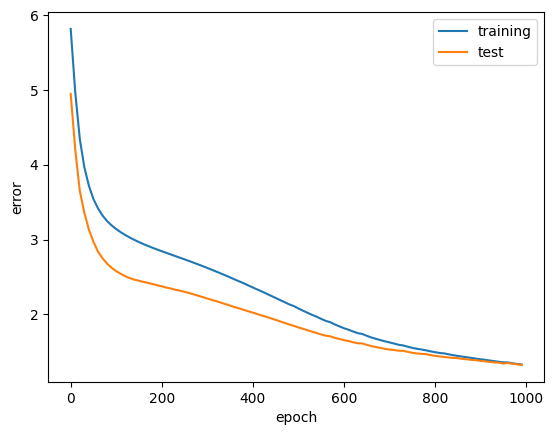

1.3211339712142944
Test loss, trainer:  1.3211339712142944
1.3159548044204712
Test loss, validator:  1.3159548044204712
Baseline loss:  4.289400100708008


In [129]:

agent_list = []
trainer_rnn_input_list = []
trainer_rnn_target_obs_list = []

rng = np.random.default_rng(SEED)

policy = trajectories.random_policy

for i in range(20):
    trainer_agent = trajectories.generate_trajectory(grid, policy, ACTION_PROBS, START_X, START_Y, START_DIRECTION, VIEW_SIZE, N_STEPS, i)
    agent_list.append(trainer_agent)
    trainer_data_inputs, trainer_data_target_obs = trajectories.prepare_data(trainer_agent)
    trainer_rnn_input_list.append(trainer_data_inputs)
    trainer_rnn_target_obs_list.append(trainer_data_target_obs)

trainer_rnn_input_stack = torch.stack(
    trainer_rnn_input_list,
    dim = 0
)
trainer_rnn_target_obs_stack = torch.stack(
    trainer_rnn_target_obs_list,
    dim = 0
)

validator_agent = trajectories.generate_trajectory(grid, policy, ACTION_PROBS, START_X, START_Y, START_DIRECTION, VIEW_SIZE, TEST_STEPS, TEST_SEED)
validator_data_inputs, validator_data_target_obs = trajectories.prepare_data(validator_agent)
validator_rnn_inputs = validator_data_inputs.unsqueeze(0)
validator_rnn_target_obs = validator_data_target_obs.unsqueeze(0)

INPUT_SIZE = trainer_rnn_input_stack.shape[2]
OUTPUT_SIZE = trainer_rnn_target_obs_stack.shape[2]
HIDDEN_SIZE = 64     


model_RNN = NN_models.BasicRNN(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_SIZE, "relu")
loss_history = model_training_evaluator.model_training(model_RNN, trainer_rnn_input_stack, trainer_rnn_target_obs_stack, validator_rnn_inputs, validator_rnn_target_obs)


model_training_evaluator.model_evaluation(model_RNN, trainer_rnn_input_stack, trainer_rnn_target_obs_stack, "trainer")
model_training_evaluator.model_evaluation(model_RNN, validator_rnn_inputs, validator_rnn_target_obs, "validator")
model_training_evaluator.baseline_evaluation(validator_rnn_inputs, validator_rnn_target_obs)



validator Error per Action Type

There are t predictions, t + 1 observations and t actions
predictions start from 

In [126]:
validator_agent_actions = validator_agent.actions
trainer_agent_actions = trainer_agent.actions

validator_action_move = []
validator_action_left = []
validator_action_right = []
validator_action_stop = []
baseline_validator_action_move = []
baseline_validator_action_left = []
baseline_validator_action_right = []
baseline_validator_action_stop = []
trainer_action_move = []
trainer_action_left = []
trainer_action_right = []
trainer_action_stop = []

model_RNN.eval()

with torch.no_grad():
    validator_pred_obs = model_RNN(validator_data_inputs)
    trainer_pred_obs = model_RNN(trainer_data_inputs)

loss_fn = nn.MSELoss(reduction = "none")


validator_loss = loss_fn(validator_data_target_obs, validator_pred_obs)
trainer_loss = loss_fn(trainer_data_target_obs, trainer_pred_obs)

observations_size = validator_data_target_obs.shape[1]
validator_data_target_obs_minusone = validator_data_inputs[:, :observations_size]

baseline_loss = loss_fn(validator_data_target_obs, validator_data_target_obs_minusone)

avg_validator_loss = validator_loss.mean(dim = 1)
avg_trainer_loss = trainer_loss.mean(dim = 1)

i = 0
for actions in validator_agent_actions:
    if actions == 0:
        validator_action_move.append(avg_validator_loss[i])
        baseline_validator_action_move.append(baseline_loss[i])
    elif actions == 1:
        validator_action_left.append(avg_validator_loss[i])
        baseline_validator_action_left.append(baseline_loss[i])
    elif actions == 2:
        validator_action_right.append(avg_validator_loss[i])
        baseline_validator_action_right.append(baseline_loss[i])
    elif actions == 3:
        validator_action_stop.append(avg_validator_loss[i])
        baseline_validator_action_stop.append(baseline_loss[i])
    i += 1

j = 0
for actions in trainer_agent_actions:
    if actions == 0:
        trainer_action_move.append(avg_trainer_loss[j])
    elif actions == 1:
        trainer_action_left.append(avg_trainer_loss[j])
    elif actions == 2:
        trainer_action_right.append(avg_trainer_loss[j])
    elif actions == 3:
        trainer_action_stop.append(avg_trainer_loss[j])
    j += 1

validator_move_loss = torch.stack(validator_action_move).mean()
validator_left_loss = torch.stack(validator_action_left).mean()
validator_right_loss = torch.stack(validator_action_right).mean()
validator_stop_loss = torch.stack(validator_action_stop).mean()
trainer_move_loss = torch.stack(trainer_action_move).mean()
trainer_left_loss = torch.stack(trainer_action_left).mean()
trainer_right_loss = torch.stack(trainer_action_right).mean()
trainer_stop_loss = torch.stack(trainer_action_stop).mean()
baseline_move_loss = torch.stack(baseline_validator_action_move).mean()
baseline_left_loss = torch.stack(baseline_validator_action_left).mean()
baseline_right_loss = torch.stack(baseline_validator_action_right).mean()
baseline_stop_loss = torch.stack(baseline_validator_action_stop).mean()

print(f"move loss: {validator_move_loss}, {len(validator_action_move)}")
print(f"left loss: {validator_left_loss}, {len(validator_action_left)}")
print(f"right loss: {validator_right_loss}, {len(validator_action_right)}")
print(f"stop loss: {validator_stop_loss}, {len(validator_action_stop)}")

print(f"trainer move loss: {trainer_move_loss}, {len(trainer_action_move)}")
print(f"trainer left loss: {trainer_left_loss}, {len(trainer_action_left)}")
print(f"trainer right loss: {trainer_right_loss}, {len(trainer_action_right)}")
print(f"trainer stop loss: {trainer_stop_loss}, {len(trainer_action_stop)}")

print(f"baseline_move loss: {baseline_move_loss}, {len(baseline_validator_action_move)}")
print(f"baseline_left loss: {baseline_left_loss}, {len(baseline_validator_action_left)}")
print(f"baseline_right loss: {baseline_right_loss}, {len(baseline_validator_action_right)}")
print(f"baseline_stop loss: {baseline_stop_loss}, {len(baseline_validator_action_stop)}")


validator_global_avg_loss = (validator_move_loss * len(validator_action_move) + validator_left_loss * len(validator_action_left) + validator_right_loss * len(validator_action_right) + validator_stop_loss * len(validator_action_stop)) / 200
trainer_global_avg_loss = (trainer_move_loss * len(trainer_action_move) + trainer_left_loss * len(trainer_action_left) + trainer_right_loss * len(trainer_action_right) + trainer_stop_loss * len(trainer_action_stop)) / 500

print(f"validator Global Average Loss: {validator_global_avg_loss}")
print(f"Trainer Global Average Loss: {trainer_global_avg_loss}")



move loss: 6.015626907348633, 127
left loss: 10.432229995727539, 25
right loss: 9.352542877197266, 31
stop loss: 8.632641792297363, 17
trainer move loss: 1.0265237092971802, 283
trainer left loss: 1.864371418952942, 77
trainer right loss: 1.9979547262191772, 82
trainer stop loss: 1.323335886001587, 58
baseline_move loss: 3.2251968383789062, 127
baseline_left loss: 7.668799877166748, 25
baseline_right loss: 8.276128768920898, 31
baseline_stop loss: 0.0, 17
validator Global Average Loss: 7.307370662689209
Trainer Global Average Loss: 1.3492971658706665


A Standard NN is memoryless, so if for two different states, the same observation is presented and the same action is chosen, the input to the NN are effectively the same, with no distinguishability. The next goal is to show that this is an issue with standard MLPs.

Find scenarios where (o_t, a_t) are equal but o_t+1 are different at the next step. then compare the predicted o_t+1 and see how similar they are one to the other

In [127]:
trainer_validator_inputs = torch.cat((trainer_data_inputs, validator_data_inputs), dim = 0)
equal_input_pairs = []

groups = {}

for i in range(len(trainer_validator_inputs)):
    key = tuple(trainer_validator_inputs[i].tolist())

    if key not in groups:
        groups[key] = []

    groups[key].append(i)

multiinput_count = 0
oneinput_count = 0
for key, number in groups.items():
    if len(number) > 1:
        print(number)
        multiinput_count += 1
    else:
        oneinput_count += 1
    if len(number) == 2:
        print(f"occurences: {len(number)}")

        key_tensor = torch.tensor(key)
        observation = key_tensor[:25].reshape(5, 5)
        action = key_tensor[25:]

        #print(observation)
        #print(action)

#print(multiinput_count)
#print(oneinput_count)


[0, 356, 418, 485, 500]
[1, 133, 419, 486, 501]
[2, 25, 46, 134, 420, 487, 502]
[3, 104, 135, 421, 470, 503, 538]
[4, 136, 422]
[5, 77, 78]
[6, 137, 258]
[8, 48, 120, 121, 123, 124, 125, 181, 182, 292, 293, 294, 295, 296, 304, 367, 369, 370, 371, 372, 437, 438, 467, 468, 489, 490, 491, 492, 511, 519, 520, 521, 522, 523, 524, 525, 526, 607]
[9, 122, 177, 178, 297, 368, 393, 606]
[10, 49, 102, 126, 175, 300, 305, 391, 394, 469, 512, 537, 597]
[11, 139, 471, 504, 539]
[12, 505]
occurences: 2
[13, 157, 235, 507]
[26, 27, 103]
[28, 47, 176, 488]
[29, 153, 179, 183, 298, 353, 373, 389, 439, 493, 515, 527, 534, 608]
[31, 51, 185, 361, 495]
[32, 96, 186, 362, 496]
[33, 432]
occurences: 2
[34, 433, 447]
[35, 448]
occurences: 2
[36, 100, 449]
[37, 249, 464]
[40, 444]
occurences: 2
[42, 84]
occurences: 2
[43, 44]
occurences: 2
[53, 82, 161, 453]
[54, 162, 454]
[55, 56, 397, 398, 399, 400, 402, 403, 404, 406, 455, 457, 458]
[57, 164, 407, 459]
[58, 108, 129, 165, 377, 408, 600]
[59, 60, 61, 62, 63

Consider which equal scenarios contain a different next observation, and also compare with predicted observation

In [128]:
trainer_validator_target_obs = torch.cat((trainer_data_target_obs, validator_data_target_obs), dim = 0)


for key, indices in groups.items():
    if len(indices) > 1:
        matching_set = set()
        for i in indices:
            target_key = tuple(trainer_validator_target_obs[i].tolist())
            matching_set.add(target_key)

        print(f"Occurences: {len(indices)}")
        print(f"Matching sets: {(len(matching_set))}")
        print(f"Indices: {indices}")





Occurences: 5
Matching sets: 2
Indices: [0, 356, 418, 485, 500]
Occurences: 5
Matching sets: 1
Indices: [1, 133, 419, 486, 501]
Occurences: 7
Matching sets: 1
Indices: [2, 25, 46, 134, 420, 487, 502]
Occurences: 7
Matching sets: 2
Indices: [3, 104, 135, 421, 470, 503, 538]
Occurences: 3
Matching sets: 1
Indices: [4, 136, 422]
Occurences: 3
Matching sets: 1
Indices: [5, 77, 78]
Occurences: 3
Matching sets: 2
Indices: [6, 137, 258]
Occurences: 38
Matching sets: 1
Indices: [8, 48, 120, 121, 123, 124, 125, 181, 182, 292, 293, 294, 295, 296, 304, 367, 369, 370, 371, 372, 437, 438, 467, 468, 489, 490, 491, 492, 511, 519, 520, 521, 522, 523, 524, 525, 526, 607]
Occurences: 8
Matching sets: 1
Indices: [9, 122, 177, 178, 297, 368, 393, 606]
Occurences: 13
Matching sets: 8
Indices: [10, 49, 102, 126, 175, 300, 305, 391, 394, 469, 512, 537, 597]
Occurences: 5
Matching sets: 1
Indices: [11, 139, 471, 504, 539]
Occurences: 2
Matching sets: 1
Indices: [12, 505]
Occurences: 4
Matching sets: 1
Indices